# QBIO 465 Final Project — Heart Failure 3-Month Mortality Prediction


Goal: predict 3-month mortality risk in hospitalized heart failure patients using structured clinical data.

Models in this notebook:
1. Logistic Regression baseline
2. Random Forest baseline
3. Multi-task Neural Network with shared layers and three outputs:
   - death within 28 days
   - death within 3 months
   - death within 6 months

Main target:
- `death.within.3.months`

## 0. Imports and settings

This project uses:
- `pandas` / `numpy` for data handling
- `matplotlib` for figures
- `sklearn` for preprocessing and baseline models
- `tensorflow.keras` for the multi-task neural network

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import joblib

# TensorFlow / Keras
# If this import fails, install TensorFlow first:
# pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. Load data

In [42]:
# Data files
DATA_PATH = "dat.csv"
DICT_PATH = "dataDictionary.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/dat.csv"

if not os.path.exists(DICT_PATH):
    DICT_PATH = "/mnt/data/dataDictionary.csv"

df = pd.read_csv(DATA_PATH)
data_dict = pd.read_csv(DICT_PATH)

print("Data shape:", df.shape)
print("Data dictionary shape:", data_dict.shape)

df.head()

Data shape: (2008, 167)
Data dictionary shape: (166, 3)


,Unnamed: 0,No.,Way.of.leaving.hospital,admission.ward,admission.way,occupation,discharge.department,visit.times,gender,body.temperature,...,body.temperature.blood.gas,oxygen.saturation,partial.oxygen.pressure,oxyhemoglobin,anion.gap,free.calcium,total.hemoglobin,GCS,dischargeDay,ageCat
0,1,1,Home,Cardiology,NonEmergency,UrbanResident,Cardiology,1,Male,36.7,...,37.0,97.0,93.0,95.9,17.8,1.14,125.0,15,11,"(69,79]"
1,2,2,Home,Cardiology,NonEmergency,UrbanResident,Cardiology,1,Female,36.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,8,"(69,79]"
2,3,3,Home,Cardiology,NonEmergency,farmer,Cardiology,2,Male,36.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,5,"(59,69]"
3,4,4,Home,Cardiology,Emergency,UrbanResident,Cardiology,1,Male,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,11,"(69,79]"
4,5,5,Home,Cardiology,NonEmergency,UrbanResident,Cardiology,1,Female,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,5,"(69,79]"


In [43]:
#  data dictionary quick look
data_dict.head(15)


,Unnamed: 0,Variables,Description
0,1,No.,The patient unique ID
1,2,Way.of.leaving.hospital,Way.of.leaving.hospital
2,3,admission.ward,admission.ward
3,4,admission.way,admission.way
4,5,occupation,occupation
5,6,discharge.department,discharge.department
6,7,visit.times,visit.times
7,8,gender,gender:
8,9,body.temperature,body.temperature
9,10,pulse,pulse


In [4]:
# Check the mortality outcome columns
target_cols = ["death.within.28.days", "death.within.3.months", "death.within.6.months"]

for col in target_cols:
    print("\n", col)
    print(df[col].value_counts())
    print("positive rate:", df[col].mean())



 death.within.28.days
death.within.28.days
0    1971
1      37
Name: count, dtype: int64
positive rate: 0.018426294820717132

 death.within.3.months
death.within.3.months
0    1966
1      42
Name: count, dtype: int64
positive rate: 0.02091633466135458

 death.within.6.months
death.within.6.months
0    1951
1      57
Name: count, dtype: int64
positive rate: 0.02838645418326693


## 2. Exploratory data analysis

1. Mortality distribution across 28 days / 3 months / 6 months
2. Missingness summary
3. Age category vs 3-month mortality
4. Gender vs 3-month mortality
5. Key clinical variable distributions
6. Correlation heatmap


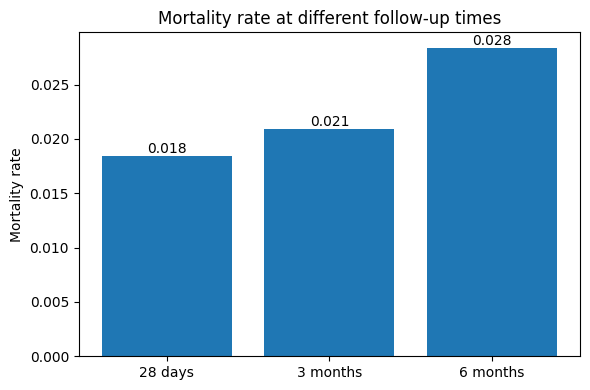

In [5]:
# Figure 1: mortality outcome distribution
outcome_names = ["28 days", "3 months", "6 months"]
death_rates = [df[c].mean() for c in target_cols]

plt.figure(figsize=(6, 4))
bars = plt.bar(outcome_names, death_rates)
plt.ylabel("Mortality rate")
plt.title("Mortality rate at different follow-up times")

for b, v in zip(bars, death_rates):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


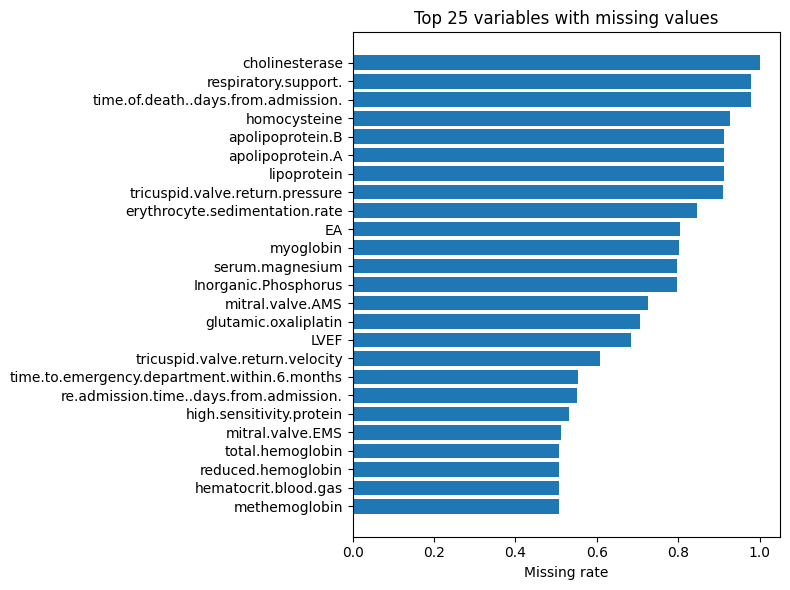

In [6]:
# Figure 2: top columns with missing values
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_top = missing_rate[missing_rate > 0].head(25)

plt.figure(figsize=(8, 6))
plt.barh(missing_top.index[::-1], missing_top.values[::-1])
plt.xlabel("Missing rate")
plt.title("Top 25 variables with missing values")
plt.tight_layout()
plt.show()


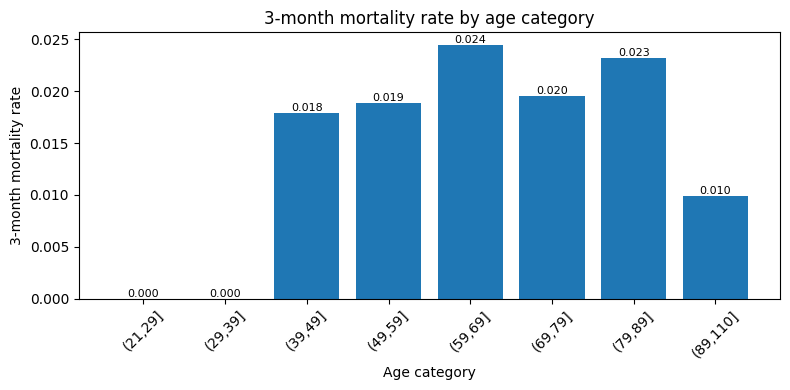

,ageCat,mean,count
0,"(21,29]",0.000000,4
1,"(29,39]",0.000000,12
2,"(39,49]",0.017857,56
3,"(49,59]",0.018868,106
4,"(59,69]",0.024457,368
5,"(69,79]",0.019580,715
6,"(79,89]",0.023220,646
7,"(89,110]",0.009901,101


In [7]:
# Figure 3: age category and 3-month mortality
target = "death.within.3.months"

age_table = df.groupby("ageCat")[target].agg(["mean", "count"]).reset_index()

plt.figure(figsize=(8, 4))
bars = plt.bar(age_table["ageCat"].astype(str), age_table["mean"])
plt.xlabel("Age category")
plt.ylabel("3-month mortality rate")
plt.title("3-month mortality rate by age category")
plt.xticks(rotation=45)

for b, v in zip(bars, age_table["mean"]):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

age_table


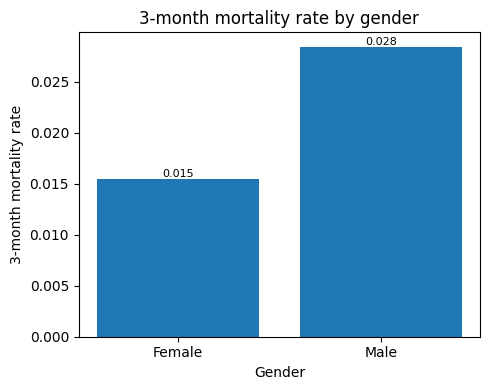

,gender,mean,count
0,Female,0.015477,1163
1,Male,0.028402,845


In [8]:
# Figure 4: gender and 3-month mortality
gender_table = df.groupby("gender")[target].agg(["mean", "count"]).reset_index()

plt.figure(figsize=(5, 4))
bars = plt.bar(gender_table["gender"].astype(str), gender_table["mean"])
plt.xlabel("Gender")
plt.ylabel("3-month mortality rate")
plt.title("3-month mortality rate by gender")

for b, v in zip(bars, gender_table["mean"]):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

gender_table


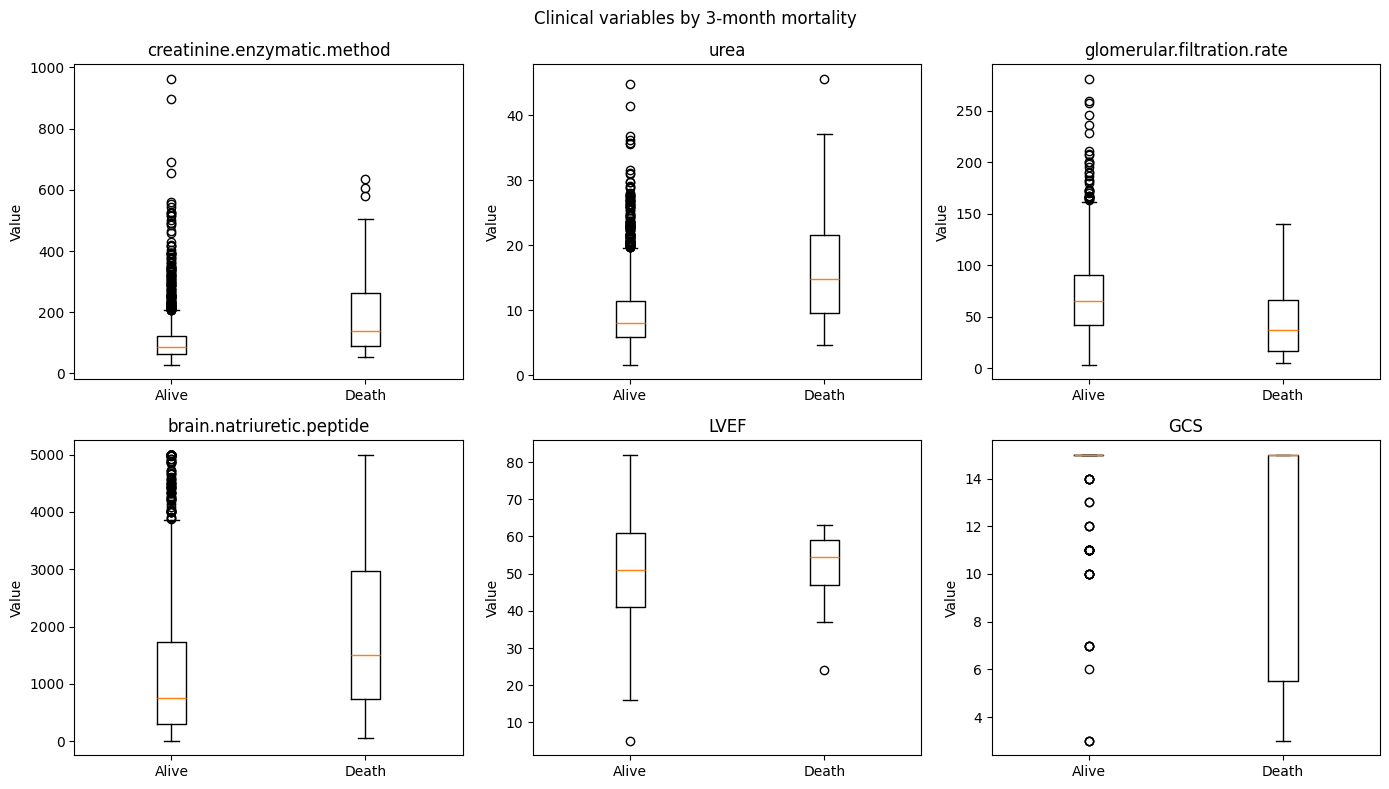

In [ ]:
# Figure 5: key clinical variable distributions by outcome
key_vars = [
    "creatinine.enzymatic.method",
    "urea",
    "glomerular.filtration.rate",
    "brain.natriuretic.peptide",
    "LVEF",
    "GCS"
]

key_vars = [c for c in key_vars if c in df.columns]

plt.figure(figsize=(14, 8))

for i, col in enumerate(key_vars):
    plt.subplot(2, 3, i + 1)

    data0 = df.loc[df[target] == 0, col].dropna()
    data1 = df.loc[df[target] == 1, col].dropna()

    plt.boxplot([data0, data1], labels=["Alive", "Death"])
    plt.title(col)
    plt.ylabel("Value")

plt.suptitle("Clinical variables by 3-month mortality")
plt.tight_layout()
plt.show()


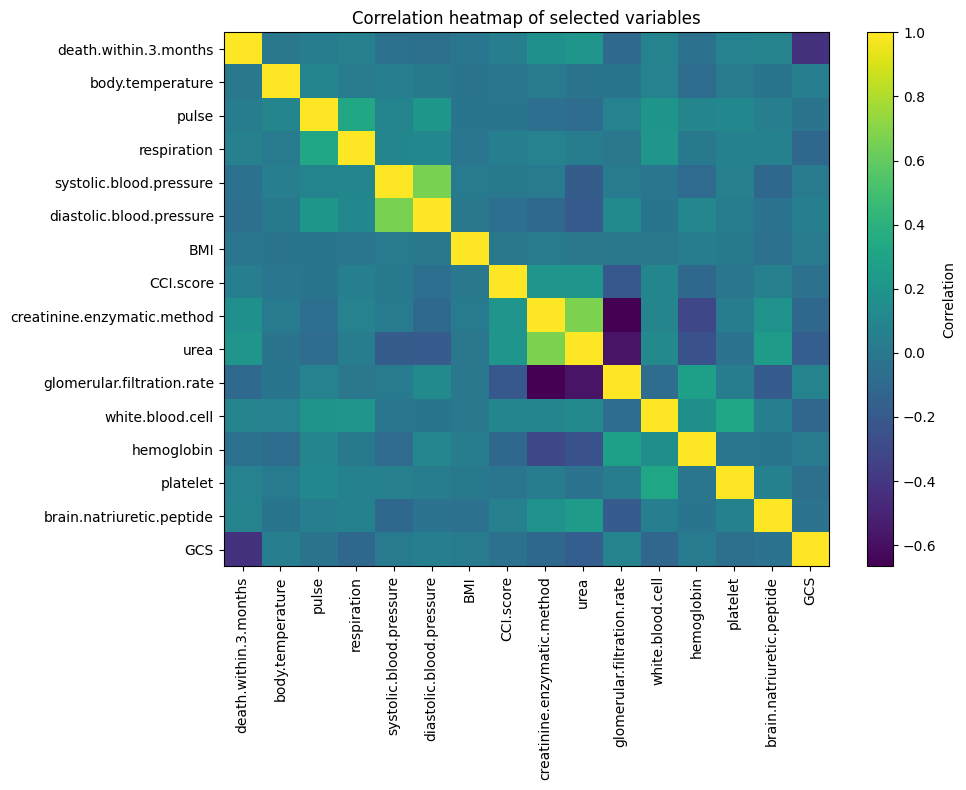

In [10]:
# Figure 6: correlation heatmap for selected numerical variables
corr_vars = [
    "death.within.3.months",
    "body.temperature",
    "pulse",
    "respiration",
    "systolic.blood.pressure",
    "diastolic.blood.pressure",
    "BMI",
    "CCI.score",
    "creatinine.enzymatic.method",
    "urea",
    "glomerular.filtration.rate",
    "white.blood.cell",
    "hemoglobin",
    "platelet",
    "brain.natriuretic.peptide",
    "GCS"
]

corr_vars = [c for c in corr_vars if c in df.columns]
corr_df = df[corr_vars].copy()

# Simple median imputation just for visualization
for c in corr_df.columns:
    corr_df[c] = corr_df[c].fillna(corr_df[c].median())

corr_mat = corr_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_mat, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_vars)), corr_vars, rotation=90)
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("Correlation heatmap of selected variables")
plt.tight_layout()
plt.show()


## 3. Prepare features

The primary label is `death.within.3.months` and I remove some leakeage

For instance, like those things
- Death labels and readmission/future outcome columns should not be used as input features
- Patient ID columns should also be removed
- 28-day and 6-month death labels are only used as **auxiliary outputs** for the multi-task neural network, not as input features


In [11]:
# Main and auxiliary targets
y_main = df["death.within.3.months"].astype(int)
y_28 = df["death.within.28.days"].astype(int)
y_6m = df["death.within.6.months"].astype(int)

# Columns that reveal patient ID or future outcomes
leakage_cols = [
    "Unnamed: 0",
    "No.",
    "Way.of.leaving.hospital",
    "discharge.department",
    "outcome.during.hospitalization",
    "death.within.28.days",
    "death.within.3.months",
    "death.within.6.months",
    "re.admission.within.28.days",
    "re.admission.within.3.months",
    "re.admission.within.6.months",
    "time.of.death..days.from.admission.",
    "re.admission.time..days.from.admission.",
    "return.to.emergency.department.within.6.months",
    "time.to.emergency.department.within.6.months",
    "dischargeDay"
]

leakage_cols = [c for c in leakage_cols if c in df.columns]

# Remove variables with very high missingness
missing_cutoff = 0.80
high_missing_cols = df.columns[df.isna().mean() > missing_cutoff].tolist()

# Final columns to drop
drop_cols = sorted(list(set(leakage_cols + high_missing_cols)))

X_raw = df.drop(columns=drop_cols)

# Remove columns with only one unique value
constant_cols = [c for c in X_raw.columns if X_raw[c].nunique(dropna=True) <= 1]
X_raw = X_raw.drop(columns=constant_cols)

print("Number of leakage columns removed:", len(leakage_cols))
print("Number of high-missing columns removed:", len(high_missing_cols))
print("Number of constant columns removed:", len(constant_cols))
print("Final feature matrix shape:", X_raw.shape)

print("\nDropped leakage columns:")
print(leakage_cols)

print("\nDropped high-missing columns:")
print(high_missing_cols)

print("\nFinal feature columns:")
print(X_raw.columns.tolist())


Number of leakage columns removed: 16
Number of high-missing columns removed: 11
Number of constant columns removed: 2
Final feature matrix shape: (2008, 139)

Dropped leakage columns:
['Unnamed: 0', 'No.', 'Way.of.leaving.hospital', 'discharge.department', 'outcome.during.hospitalization', 'death.within.28.days', 'death.within.3.months', 'death.within.6.months', 're.admission.within.28.days', 're.admission.within.3.months', 're.admission.within.6.months', 'time.of.death..days.from.admission.', 're.admission.time..days.from.admission.', 'return.to.emergency.department.within.6.months', 'time.to.emergency.department.within.6.months', 'dischargeDay']

Dropped high-missing columns:
['respiratory.support.', 'EA', 'tricuspid.valve.return.pressure', 'time.of.death..days.from.admission.', 'myoglobin', 'cholinesterase', 'erythrocyte.sedimentation.rate', 'homocysteine', 'apolipoprotein.A', 'apolipoprotein.B', 'lipoprotein']

Final feature columns:
['admission.ward', 'admission.way', 'occupation

In [44]:
# Train/test split
X_train_raw, X_test_raw, y_train, y_test, y28_train, y28_test, y6_train, y6_test = train_test_split(
    X_raw,
    y_main,
    y_28,
    y_6m,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_main
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("3-month mortality train counts:")
print(y_train.value_counts())
print("3-month mortality test counts:")
print(y_test.value_counts())


X_train_raw: (1606, 139)
X_test_raw: (402, 139)
3-month mortality train counts:
death.within.3.months
0    1572
1      34
Name: count, dtype: int64
3-month mortality test counts:
death.within.3.months
0    394
1      8
Name: count, dtype: int64


## 4. Build preprocessing pipeline

In [ ]:
# Separate numerical and categorical features
num_cols = X_train_raw.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot)
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])


Number of numerical columns: 128
Number of categorical columns: 11


In [14]:
# Helper function to get feature names after preprocessing
def get_feature_names(preprocessor, num_cols, cat_cols):
    feature_names = []

    # numerical names
    feature_names.extend(num_cols)

    # categorical one-hot names
    try:
        cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(cat_names)
    except Exception:
        # fallback if sklearn version is older
        feature_names.extend(cat_cols)

    return feature_names


## 5. Helper functions for model evaluation

Because the mortality label is imbalanced, so that we report those scores and testing criiteria
- accuracy
- precision
- recall
- F1 score
- ROC-AUC
- PR-AUC

In [15]:
def get_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Threshold": threshold
    }

    return results


def find_best_threshold_by_f1(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold = 0.5
    best_f1 = -1

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = th

    return best_threshold, best_f1


def plot_confusion_matrix_simple(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Alive", "Death"])
    plt.yticks([0, 1], ["Alive", "Death"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return cm


## 6. Baseline models with 5-fold cross-validation

In [ ]:
# Tuned baseline models with 5-fold cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "f1": "f1",
    "precision": "precision"
}

# Logistic Regression baseline
logreg_base = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

logreg_param_grid = {
    "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "model__penalty": ["l1", "l2"]
}

logreg_search = RandomizedSearchCV(
    logreg_base,
    param_distributions=logreg_param_grid,
    n_iter=14,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Random Forest baseline
rf_base = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Tuning Logistic Regression by CV PR-AUC...")
logreg_search.fit(X_train_raw, y_train)

print("Tuning Random Forest by CV PR-AUC...")
rf_search.fit(X_train_raw, y_train)

print("\nBest Logistic Regression parameters:")
print(logreg_search.best_params_)
print("Best Logistic Regression CV PR-AUC:", logreg_search.best_score_)

print("\nBest Random Forest parameters:")
print(rf_search.best_params_)
print("Best Random Forest CV PR-AUC:", rf_search.best_score_)

# Use the tuned models for the rest of the notebook
logreg_pipe = logreg_search.best_estimator_
rf_pipe = rf_search.best_estimator_

print("\nRunning 5-fold CV for tuned Logistic Regression...")
logreg_cv = cross_validate(logreg_pipe, X_train_raw, y_train, cv=cv, scoring=scoring)

print("Running 5-fold CV for tuned Random Forest...")
rf_cv = cross_validate(rf_pipe, X_train_raw, y_train, cv=cv, scoring=scoring)

def summarize_cv(cv_result, model_name):
    row = {"Model": model_name}
    for key in scoring.keys():
        vals = cv_result[f"test_{key}"]
        row[f"{key}_mean"] = np.mean(vals)
        row[f"{key}_std"] = np.std(vals)
    return row

cv_summary = pd.DataFrame([
    summarize_cv(logreg_cv, "Logistic Regression"),
    summarize_cv(rf_cv, "Random Forest")
])

cv_summary


Tuning Logistic Regression by CV PR-AUC...
Tuning Random Forest by CV PR-AUC...

Best Logistic Regression parameters:
{'model__penalty': 'l1', 'model__C': 0.01}
Best Logistic Regression CV PR-AUC: 0.3333719856637877

Best Random Forest parameters:
{'model__n_estimators': 800, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None, 'model__class_weight': 'balanced_subsample'}
Best Random Forest CV PR-AUC: 0.4200992864018381

Running 5-fold CV for tuned Logistic Regression...
Running 5-fold CV for tuned Random Forest...


,Model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,f1_mean,f1_std,precision_mean,precision_std
0,Logistic Regression,0.832819,0.098906,0.333372,0.223171,0.52381,0.204263,0.198569,0.065664,0.122895,0.038831
1,Random Forest,0.899146,0.059730,0.420099,0.184389,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


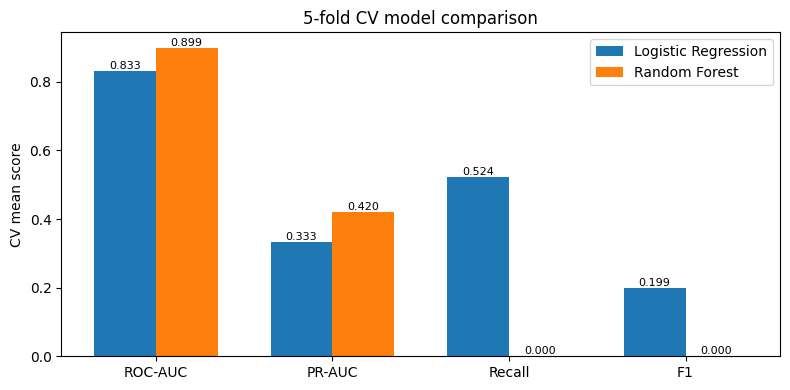

In [17]:
# Figure 7: Cross-validation comparison
metrics_to_plot = ["roc_auc_mean", "pr_auc_mean", "recall_mean", "f1_mean"]
x = np.arange(len(metrics_to_plot))
width = 0.35

lr_vals = cv_summary.loc[cv_summary["Model"] == "Logistic Regression", metrics_to_plot].values.flatten()
rf_vals = cv_summary.loc[cv_summary["Model"] == "Random Forest", metrics_to_plot].values.flatten()

plt.figure(figsize=(8, 4))
bars1 = plt.bar(x - width/2, lr_vals, width, label="Logistic Regression")
bars2 = plt.bar(x + width/2, rf_vals, width, label="Random Forest")

plt.xticks(x, ["ROC-AUC", "PR-AUC", "Recall", "F1"])
plt.ylabel("CV mean score")
plt.title("5-fold CV model comparison")
plt.legend()

for bars in [bars1, bars2]:
    for b in bars:
        plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


Making out-of-fold predictions for tuned Logistic Regression...
Making out-of-fold predictions for tuned Random Forest...


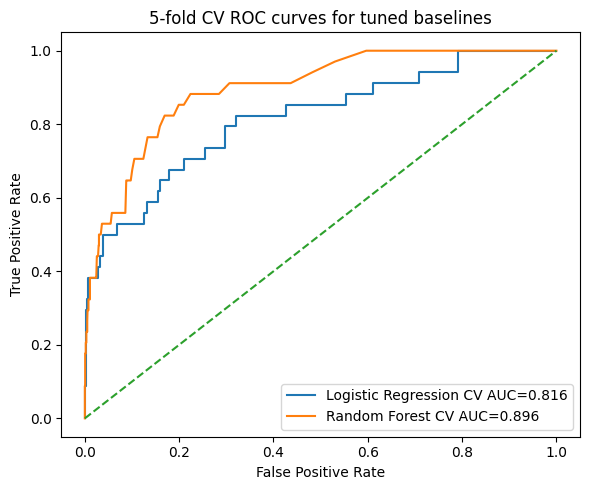

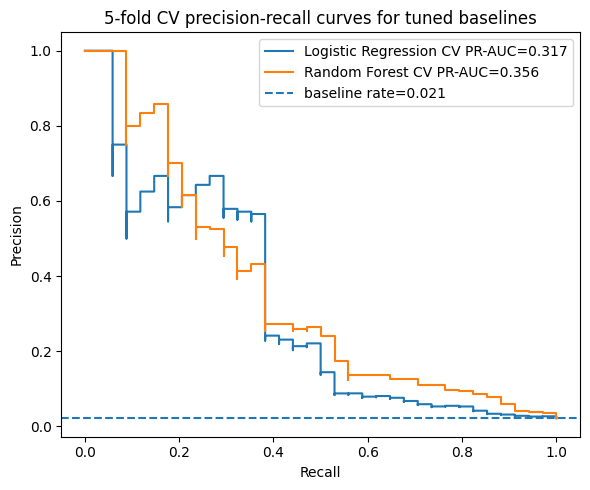

In [ ]:
# Figure 7b: Cross-validated ROC and PR curves for the tuned baseline models

print("Making out-of-fold predictions for tuned Logistic Regression...")
logreg_oof_prob = cross_val_predict(
    logreg_pipe,
    X_train_raw,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Making out-of-fold predictions for tuned Random Forest...")
rf_oof_prob = cross_val_predict(
    rf_pipe,
    X_train_raw,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# CV ROC curves
plt.figure(figsize=(6, 5))

for model_name, prob in [
    ("Logistic Regression", logreg_oof_prob),
    ("Random Forest", rf_oof_prob)
]:
    fpr, tpr, _ = roc_curve(y_train, prob)
    auc_val = roc_auc_score(y_train, prob)
    plt.plot(fpr, tpr, label=f"{model_name} CV AUC={auc_val:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5-fold CV ROC curves for tuned baselines")
plt.legend()
plt.tight_layout()
plt.show()

# CV precision-recall curves
plt.figure(figsize=(6, 5))

for model_name, prob in [
    ("Logistic Regression", logreg_oof_prob),
    ("Random Forest", rf_oof_prob)
]:
    precision, recall, _ = precision_recall_curve(y_train, prob)
    ap_val = average_precision_score(y_train, prob)
    plt.step(recall, precision, where="post", label=f"{model_name} CV PR-AUC={ap_val:.3f}")

baseline_rate = np.mean(y_train)
plt.axhline(baseline_rate, linestyle="--", label=f"baseline rate={baseline_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("5-fold CV precision-recall curves for tuned baselines")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Train baselines and tune threshold on validation set

We split the training set again into train/validation.  
The validation set is used to choose a probability threshold that improves F1 score.


In [19]:
# Split training data again for threshold tuning
X_train2_raw, X_val_raw, y_train2, y_val, y28_train2, y28_val, y6_train2, y6_val = train_test_split(
    X_train_raw,
    y_train,
    y28_train,
    y6_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train2:", X_train2_raw.shape)
print("Validation:", X_val_raw.shape)


Train2: (1284, 139)
Validation: (322, 139)


In [20]:
# Fit baseline models on train2
logreg_pipe.fit(X_train2_raw, y_train2)
rf_pipe.fit(X_train2_raw, y_train2)

# Validation probabilities
logreg_val_prob = logreg_pipe.predict_proba(X_val_raw)[:, 1]
rf_val_prob = rf_pipe.predict_proba(X_val_raw)[:, 1]

# Choose threshold by validation F1
logreg_best_th, logreg_val_f1 = find_best_threshold_by_f1(y_val, logreg_val_prob)
rf_best_th, rf_val_f1 = find_best_threshold_by_f1(y_val, rf_val_prob)

print("Logistic best threshold:", logreg_best_th, "validation F1:", logreg_val_f1)
print("RF best threshold:", rf_best_th, "validation F1:", rf_val_f1)


Logistic best threshold: 0.77 validation F1: 0.2857142857142857
RF best threshold: 0.09999999999999999 validation F1: 0.4


In [21]:
# Test probabilities
logreg_test_prob = logreg_pipe.predict_proba(X_test_raw)[:, 1]
rf_test_prob = rf_pipe.predict_proba(X_test_raw)[:, 1]

logreg_test_metrics = get_metrics(y_test, logreg_test_prob, threshold=logreg_best_th)
rf_test_metrics = get_metrics(y_test, rf_test_prob, threshold=rf_best_th)

baseline_test_summary = pd.DataFrame([
    {"Model": "Logistic Regression", **logreg_test_metrics},
    {"Model": "Random Forest", **rf_test_metrics}
])

baseline_test_summary


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Threshold
0,Logistic Regression,0.977612,0.4,0.25,0.307692,0.804251,0.209825,0.77
1,Random Forest,0.965174,0.2,0.25,0.222222,0.875793,0.331400,0.10


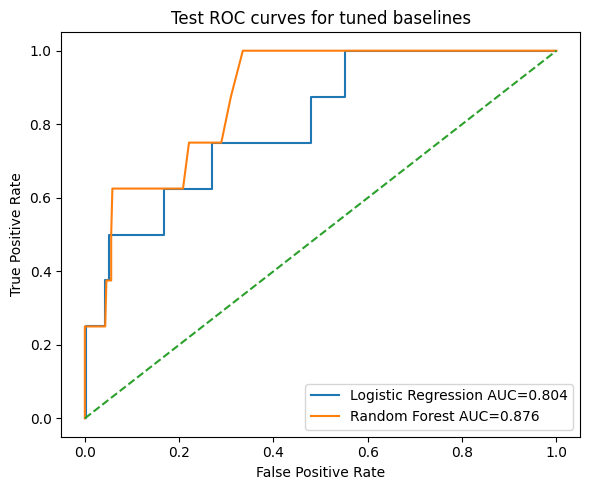

Number of positive death cases in test set: 8


In [ ]:
# Figure 8: ROC curves for tuned baseline models on the test set
# The test set has very few death cases, so the ROC curve can look step-like.

plt.figure(figsize=(6, 5))

for model_name, prob in [
    ("Logistic Regression", logreg_test_prob),
    ("Random Forest", rf_test_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc_val:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC curves for tuned baselines")
plt.legend()
plt.tight_layout()
plt.show()

print("Number of positive death cases in test set:", int(np.sum(y_test)))


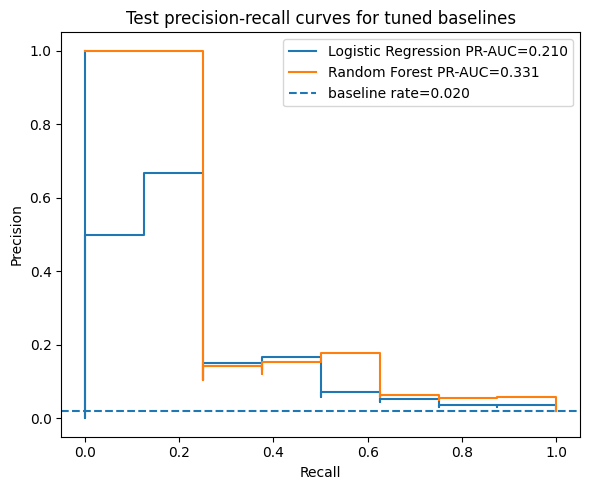

Number of positive death cases in test set: 8


In [ ]:
# Figure 9: Precision-recall curves for tuned baseline models on the test set

plt.figure(figsize=(6, 5))

for model_name, prob in [
    ("Logistic Regression", logreg_test_prob),
    ("Random Forest", rf_test_prob)
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap_val = average_precision_score(y_test, prob)
    plt.step(recall, precision, where="post", label=f"{model_name} PR-AUC={ap_val:.3f}")

baseline_rate = np.mean(y_test)
plt.axhline(baseline_rate, linestyle="--", label=f"baseline rate={baseline_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test precision-recall curves for tuned baselines")
plt.legend()
plt.tight_layout()
plt.show()

print("Number of positive death cases in test set:", int(np.sum(y_test)))


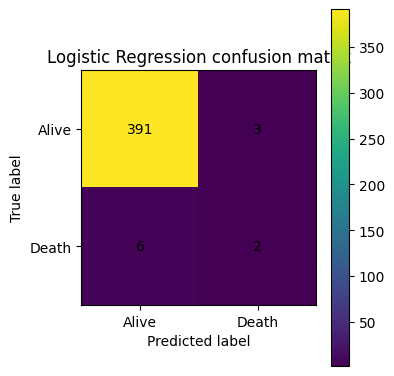

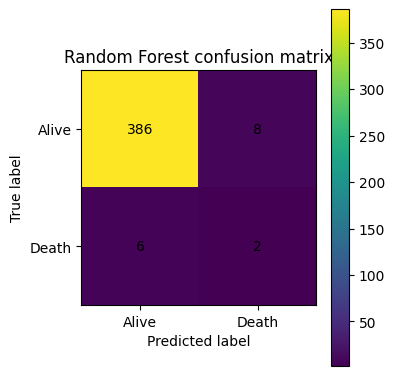

In [24]:
# Figure 10: confusion matrices for baseline models
cm_lr = plot_confusion_matrix_simple(
    y_test,
    logreg_test_prob,
    logreg_best_th,
    "Logistic Regression confusion matrix"
)

cm_rf = plot_confusion_matrix_simple(
    y_test,
    rf_test_prob,
    rf_best_th,
    "Random Forest confusion matrix"
)


## 8. Multi-task neural network

This model jointly learns:
- 28-day mortality
- 3-month mortality
- 6-month mortality

The shared hidden layers learn common clinical risk patterns,
sincethis dataset is small and the positive mortality class is very rare.  
A large neural network can overfit quickly, so we use a smaller architecture, dropout, L2 regularization, lower learning rate, and early stopping.


In [25]:
# Preprocess data for neural network
# We fit the preprocessor only on train2 to avoid leakage.
nn_preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_nn_train = nn_preprocessor.fit_transform(X_train2_raw)
X_nn_val = nn_preprocessor.transform(X_val_raw)
X_nn_test = nn_preprocessor.transform(X_test_raw)

X_nn_train = X_nn_train.astype("float32")
X_nn_val = X_nn_val.astype("float32")
X_nn_test = X_nn_test.astype("float32")

print("NN train shape:", X_nn_train.shape)
print("NN val shape:", X_nn_val.shape)
print("NN test shape:", X_nn_test.shape)


NN train shape: (1284, 167)
NN val shape: (322, 167)
NN test shape: (402, 167)


In [45]:
# Helper function for sample weights
# To keep NN training stable, we use class weights mainly for the main 3-month output (cuz mortality rate ver imbalanced)

def make_sample_weight(y):
    classes = np.array([0, 1])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.array(y))
    weight_dict = {0: weights[0], 1: weights[1]}
    return np.array([weight_dict[int(v)] for v in y]).astype("float32")


def make_y_array(y):
    return np.array(y).astype("float32").reshape(-1, 1)


w3_train = make_sample_weight(y_train2)

w3_train = np.clip(w3_train, 0.5, 8.0)

# For auxiliary outputs, use normal weights
w28_train = np.ones(len(y28_train2), dtype="float32")
w6_train = np.ones(len(y6_train2), dtype="float32")

print("3-month positive rate in train2:", np.mean(y_train2))
print("3-month sample weights after clipping:", np.unique(w3_train, return_counts=True))

3-month positive rate in train2: 0.02102803738317757
3-month sample weights after clipping: (array([0.51073986, 8.        ], dtype=float32), array([1257,   27]))


In [ ]:
# Build a multi-task neural network

from tensorflow.keras import regularizers

input_dim = X_nn_train.shape[1]

inputs = keras.Input(shape=(input_dim,), name="clinical_features")

x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(inputs)
x = layers.Dropout(0.50)(x)

x = layers.Dense(
    16,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)
x = layers.Dropout(0.30)(x)

out_28 = layers.Dense(1, activation="sigmoid", name="death_28")(x)
out_3m = layers.Dense(1, activation="sigmoid", name="death_3m")(x)
out_6m = layers.Dense(1, activation="sigmoid", name="death_6m")(x)

multi_model = keras.Model(inputs=inputs, outputs=[out_28, out_3m, out_6m])

# Use list format because it is more stable for multi-output models in Keras.
# Output order is: death_28, death_3m, death_6m.
multi_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=[
        "binary_crossentropy",
        "binary_crossentropy",
        "binary_crossentropy"
    ],
    loss_weights=[0.2, 1.0, 0.2],
    metrics=[
        [keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")],
        [keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")],
        [keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")]
    ]
)

multi_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ clinical_features   │ (None, 167)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      5,376 │ clinical_feature… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ death_28 (Dense)    │ (None, 1)         │         17 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ death_3m (Dense)    │ (None, 1)         │         17 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ death_6m (Dense)    │ (None, 1)         │         17 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,955 (23.26 KB)

 Trainable params: 5,955 (23.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train multi-task neural network
# using ordered list: 1 = death_28, 2 = death_3m, 3 = death_6m

y_train_list = [
    make_y_array(y28_train2),
    make_y_array(y_train2),
    make_y_array(y6_train2)
]

y_val_list = [
    make_y_array(y28_val),
    make_y_array(y_val),
    make_y_array(y6_val)
]

w_train_list = [
    w28_train,
    w3_train,
    w6_train
]

print("Model outputs:", multi_model.output_names)
print("X_nn_train shape:", X_nn_train.shape)
print("y shapes:", [y.shape for y in y_train_list])
print("weight shapes:", [w.shape for w in w_train_list])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_nn = multi_model.fit(
    X_nn_train,
    y_train_list,
    sample_weight=w_train_list,
    validation_data=(X_nn_val, y_val_list),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Model outputs: ListWrapper(['death_28', 'death_3m', 'death_6m'])
X_nn_train shape: (1284, 167)
y shapes: [(1284, 1), (1284, 1), (1284, 1)]
weight shapes: [(1284,), (1284,), (1284,)]
Epoch 1/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - death_28_accuracy: 0.9252 - death_28_auc: 0.2340 - death_28_loss: 0.3753 - death_3m_accuracy: 0.4782 - death_3m_auc: 0.6304 - death_3m_loss: 0.5312 - death_6m_accuracy: 0.6301 - death_6m_auc: 0.5148 - death_6m_loss: 0.7089 - loss: 0.8290 - val_death_28_accuracy: 0.9752 - val_death_28_auc: 0.3714 - val_death_28_loss: 0.3481 - val_death_3m_accuracy: 0.4565 - val_death_3m_auc: 0.3231 - val_death_3m_loss: 0.7758 - val_death_6m_accuracy: 0.6801 - val_death_6m_auc: 0.4215 - val_death_6m_loss: 0.6032 - val_loss: 1.0467
Epoch 2/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - death_28_accuracy: 0.9237 - death_28_auc: 0.2932 - death_28_loss: 0.3777 - death_3m_accuracy: 0.5288 - death_3m_auc: 0.5556 - death_3m_loss: 0.5287 - death_6m_accuracy: 0.6386 - death_6m_auc: 0.5

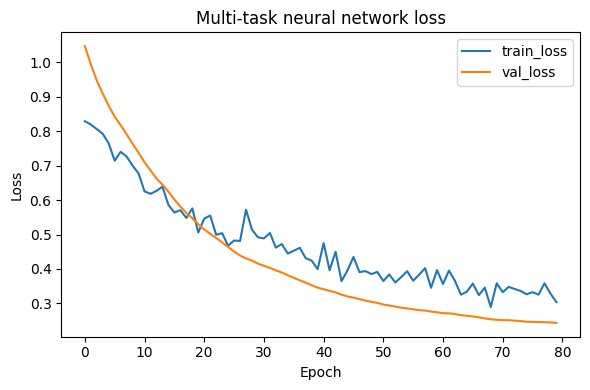

In [29]:
# Figure 11: neural network training loss
plt.figure(figsize=(6, 4))
plt.plot(history_nn.history["loss"], label="train_loss")
plt.plot(history_nn.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-task neural network loss")
plt.legend()
plt.tight_layout()
plt.show()


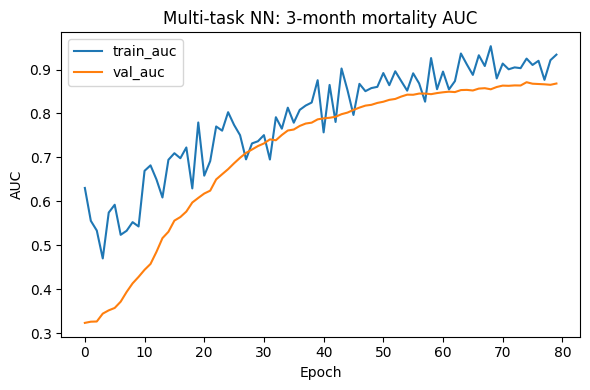

In [ ]:
# Figure 12: 3-month mortality AUC history 
key_train = "death_3m_auc"
key_val = "val_death_3m_auc"

if key_train in history_nn.history and key_val in history_nn.history:
    plt.figure(figsize=(6, 4))
    plt.plot(history_nn.history[key_train], label="train_auc")
    plt.plot(history_nn.history[key_val], label="val_auc")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Multi-task NN: 3-month mortality AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("AUC history keys were not found. Available keys:")
    print(history_nn.history.keys())


In [31]:
# Predict validation and test probabilities
val_pred_28, val_pred_3m, val_pred_6m = multi_model.predict(X_nn_val, verbose=0)
test_pred_28, test_pred_3m, test_pred_6m = multi_model.predict(X_nn_test, verbose=0)

nn_val_prob = val_pred_3m.flatten()
nn_test_prob = test_pred_3m.flatten()

# Threshold chosen on validation set
nn_best_th, nn_val_f1 = find_best_threshold_by_f1(y_val, nn_val_prob)

print("NN best threshold:", nn_best_th)
print("NN validation F1:", nn_val_f1)

nn_test_metrics = get_metrics(y_test, nn_test_prob, threshold=nn_best_th)

nn_test_summary = pd.DataFrame([
    {"Model": "Multi-task Neural Network", **nn_test_metrics}
])

nn_test_summary


NN best threshold: 0.39
NN validation F1: 0.35294117647058826


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Threshold
0,Multi-task Neural Network,0.952736,0.176471,0.375,0.24,0.762056,0.277587,0.39


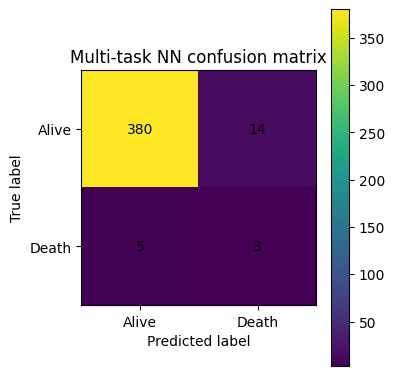

In [32]:
# Figure 13: neural network confusion matrix
cm_nn = plot_confusion_matrix_simple(
    y_test,
    nn_test_prob,
    nn_best_th,
    "Multi-task NN confusion matrix"
)


## 9. Final model comparison

In [33]:
# Combine all test results
final_summary = pd.concat([baseline_test_summary, nn_test_summary], ignore_index=True)
final_summary


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Threshold
0,Logistic Regression,0.977612,0.400000,0.250,0.307692,0.804251,0.209825,0.77
1,Random Forest,0.965174,0.200000,0.250,0.222222,0.875793,0.331400,0.10
2,Multi-task Neural Network,0.952736,0.176471,0.375,0.240000,0.762056,0.277587,0.39


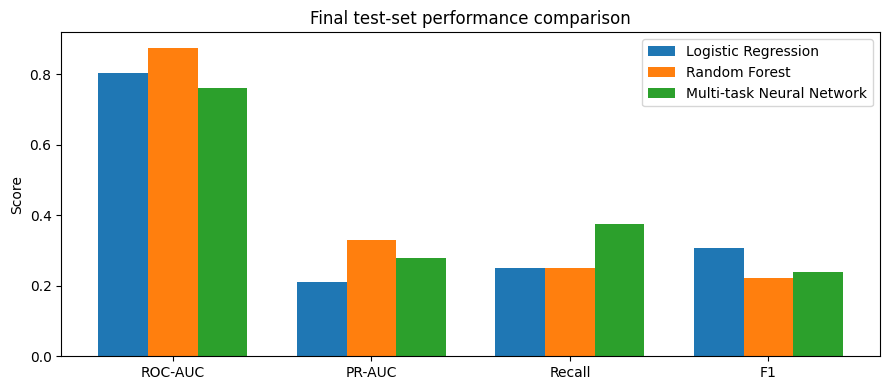

In [34]:
# Figure 14: final model comparison
metrics_to_plot = ["ROC_AUC", "PR_AUC", "Recall", "F1"]

x = np.arange(len(metrics_to_plot))
width = 0.25

plt.figure(figsize=(9, 4))

for i, model_name in enumerate(final_summary["Model"]):
    vals = final_summary.loc[final_summary["Model"] == model_name, metrics_to_plot].values.flatten()
    plt.bar(x + (i - 1) * width, vals, width, label=model_name)

plt.xticks(x, ["ROC-AUC", "PR-AUC", "Recall", "F1"])
plt.ylabel("Score")
plt.title("Final test-set performance comparison")
plt.legend()

plt.tight_layout()
plt.show()


## 10. Feature analysis and interpretability

use those two to compare
- logistic regression coefficients
- random forest feature importance



In [35]:
# Fit final logistic regression and random forest on the full training set
logreg_pipe.fit(X_train_raw, y_train)
rf_pipe.fit(X_train_raw, y_train)

# Get feature names from fitted preprocessor
fitted_preprocessor_lr = logreg_pipe.named_steps["preprocess"]
feature_names = get_feature_names(fitted_preprocessor_lr, num_cols, cat_cols)

print("Number of transformed feature names:", len(feature_names))


Number of transformed feature names: 167


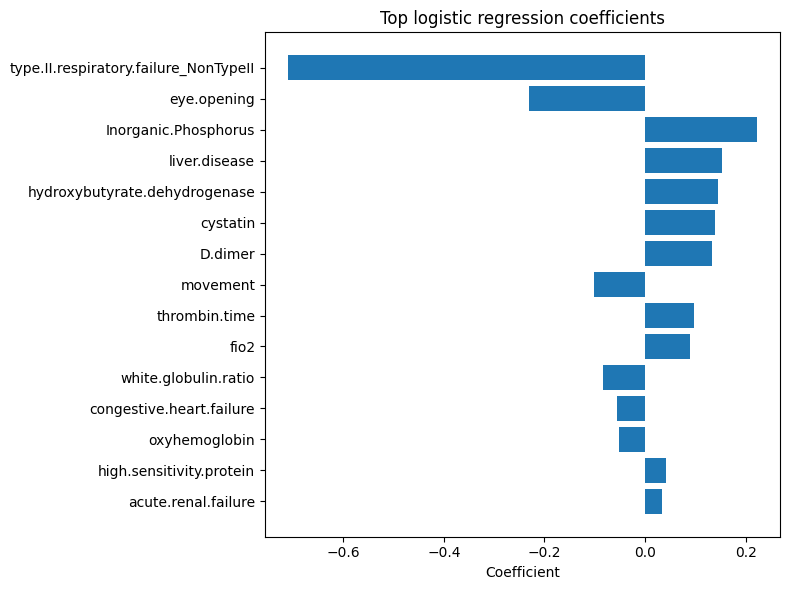

,feature,coef,abs_coef
151,type.II.respiratory.failure_NonTypeII,-0.709178,0.709178
26,eye.opening,-0.229916,0.229916
76,Inorganic.Phosphorus,0.221650,0.221650
23,liver.disease,0.153020,0.153020
80,hydroxybutyrate.dehydrogenase,0.145680,0.145680
40,cystatin,0.138247,0.138247
63,D.dimer,0.132379,0.132379
28,movement,-0.101088,0.101088
66,thrombin.time,0.096670,0.096670
29,fio2,0.088378,0.088378


In [36]:
# Figure 15: top logistic regression coefficients
logreg_model = logreg_pipe.named_steps["model"]
coef = logreg_model.coef_.flatten()

coef_df = pd.DataFrame({
    "feature": feature_names[:len(coef)],
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

top_coef = coef_df.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_coef["feature"], top_coef["coef"])
plt.xlabel("Coefficient")
plt.title("Top logistic regression coefficients")
plt.tight_layout()
plt.show()

coef_df.head(20)


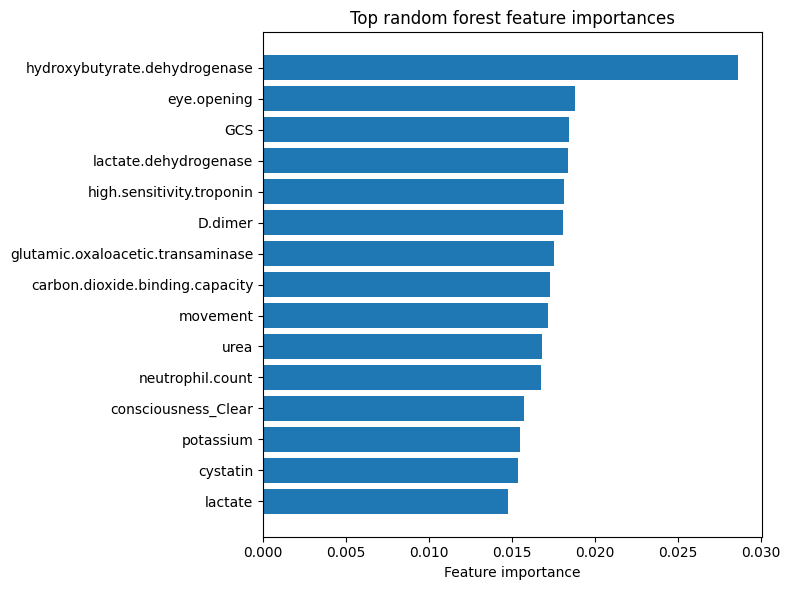

,feature,importance
80,hydroxybutyrate.dehydrogenase,0.028657
26,eye.opening,0.018785
127,GCS,0.018449
84,lactate.dehydrogenase,0.018406
70,high.sensitivity.troponin,0.018124
63,D.dimer,0.018110
81,glutamic.oxaloacetic.transaminase,0.017522
71,carbon.dioxide.binding.capacity,0.017330
28,movement,0.017157
37,urea,0.016835


In [37]:
# Figure 16: top random forest feature importances
rf_model = rf_pipe.named_steps["model"]
importances = rf_model.feature_importances_

rf_imp_df = pd.DataFrame({
    "feature": feature_names[:len(importances)],
    "importance": importances
}).sort_values("importance", ascending=False)

top_imp = rf_imp_df.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Feature importance")
plt.title("Top random forest feature importances")
plt.tight_layout()
plt.show()

rf_imp_df.head(20)


## 11. Risk stratification

In [46]:
# Choose the best model by PR-AUC
best_row = final_summary.sort_values("PR_AUC", ascending=False).iloc[0]
best_model_name = best_row["Model"]

if best_model_name == "Logistic Regression":
    best_prob = logreg_test_prob
elif best_model_name == "Random Forest":
    best_prob = rf_test_prob
else:
    best_prob = nn_test_prob

# Make sure predicted risk is a 1D array
best_prob = np.asarray(best_prob).reshape(-1)

risk_df = pd.DataFrame({
    "true_3m_death": np.array(y_test),
    "predicted_risk": best_prob
})

print("Best model by PR-AUC:", best_model_name)
print("Number of unique predicted risks:", risk_df["predicted_risk"].nunique())
print(risk_df["predicted_risk"].describe())

# Use ranked predicted risk for quartile groups
risk_df["risk_rank"] = risk_df["predicted_risk"].rank(method="first")

risk_df["risk_group"] = pd.qcut(
    risk_df["risk_rank"],
    q=4,
    labels=["Low", "Medium-low", "Medium-high", "High"]
)

risk_summary = (
    risk_df
    .groupby("risk_group", observed=False)["true_3m_death"]
    .agg(["mean", "count"])
    .reset_index()
)

risk_summary = risk_summary.rename(columns={
    "mean": "observed_3m_mortality_rate",
    "count": "n_patients"
})

risk_summary


Best model by PR-AUC: Random Forest
Number of unique predicted risks: 63
count    402.000000
mean       0.017121
std        0.033650
min        0.000000
25%        0.003750
50%        0.007500
75%        0.017500
max        0.407500
Name: predicted_risk, dtype: float64


,risk_group,observed_3m_mortality_rate,n_patients
0,Low,0.000000,101
1,Medium-low,0.000000,100
2,Medium-high,0.020000,100
3,High,0.059406,101


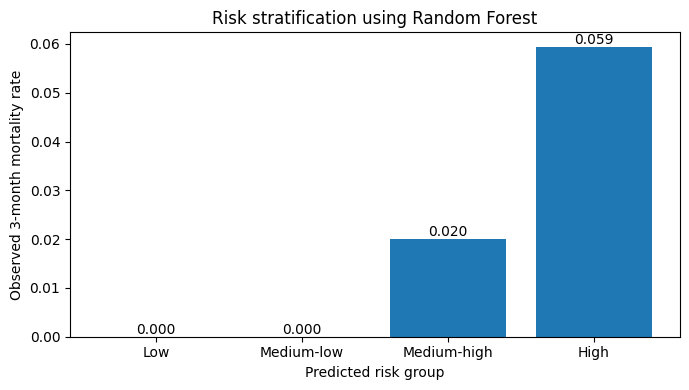

In [39]:
# Figure 17: mortality rate by predicted risk group
plt.figure(figsize=(7, 4))

bars = plt.bar(
    risk_summary["risk_group"].astype(str),
    risk_summary["observed_3m_mortality_rate"]
)

plt.xlabel("Predicted risk group")
plt.ylabel("Observed 3-month mortality rate")
plt.title(f"Risk stratification using {best_model_name}")

for b, v in zip(bars, risk_summary["observed_3m_mortality_rate"]):
    plt.text(
        b.get_x() + b.get_width()/2,
        v,
        f"{v:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 12. Save results

In [40]:
# Save result tables for the final report
final_summary.to_csv("final_model_performance_summary.csv", index=False)
cv_summary.to_csv("cv_model_performance_summary.csv", index=False)
coef_df.to_csv("logistic_regression_coefficients.csv", index=False)
rf_imp_df.to_csv("random_forest_feature_importance.csv", index=False)
risk_summary.to_csv("risk_group_summary.csv", index=False)

# Save baseline models
joblib.dump(logreg_pipe, "logistic_regression_pipeline.joblib")
joblib.dump(rf_pipe, "random_forest_pipeline.joblib")

# Save neural network and preprocessor
multi_model.save("multitask_heart_failure_model.keras")
joblib.dump(nn_preprocessor, "nn_preprocessor.joblib")

print("Saved tables and models.")


Saved tables and models.
